In [ ]:
import torch
import torch.nn as nn

import timm

import numpy as np

from tqdm import tqdm

from sklearn.datasets import fetch_openml

from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cpu


In [ ]:
usps = fetch_openml(
    "USPS",
    version=1,
    as_frame=False
)


X = usps.data


# IMPORTANT LABEL FIX
y = usps.target.astype(int)


# Convert 1-10 labels into 0-9
y = y - 1



print(X.shape)

print(y.shape)

print(np.unique(y))

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:1030: UserWarning: Version 1 of dataset USPS is inactive, meaning that issues have been found in the dataset. Try using a newer version from this URL: https://openml.org/data/v1/download/18805612/USPS.arff
  warn(


(9298, 256)
(9298,)
[0 1 2 3 4 5 6 7 8 9]


In [ ]:
class USPSDataset(Dataset):

    def __init__(
        self,
        X,
        y,
        transform=None
    ):

        self.X = X

        self.y = y

        self.transform = transform



    def __len__(self):

        return len(self.X)



    def __getitem__(self,index):


        image = self.X[index]


        image = image.reshape(
            16,
            16
        )


        image = image.astype(
            np.float32
        )


        image = torch.tensor(
            image
        )


        image = image.unsqueeze(0)



        label = self.y[index]



        if self.transform:

            image = self.transform(
                image
            )


        return image,label

In [ ]:
transform = transforms.Compose([


    transforms.Resize(
        (224,224)
    ),


    transforms.Lambda(
        lambda x:x.repeat(3,1,1)
    ),


    transforms.Normalize(

        mean=[
            0.5,
            0.5,
            0.5
        ],

        std=[
            0.5,
            0.5,
            0.5
        ]

    )

])

In [ ]:
dataset = USPSDataset(

    X,

    y,

    transform

)


print(
    len(dataset)
)

9298


In [ ]:
train_indices,test_indices = train_test_split(

    np.arange(
        len(dataset)
    ),

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [ ]:
train_dataset = Subset(

    dataset,

    train_indices

)



test_dataset = Subset(

    dataset,

    test_indices

)



print(
len(train_dataset),
len(test_dataset)
)

7438 1860


In [ ]:
train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=2

)



test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2

)

In [ ]:
images,labels = next(iter(train_loader))


print(images.shape)

print(labels.min())

print(labels.max())

torch.Size([64, 3, 224, 224])
tensor(0)
tensor(9)


# **BASELINE**

In [ ]:
# ===============================
# ViT-Tiny Model
# ===============================


model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model = model.to(device)


print(
    "USPS ViT-Tiny model loaded"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

USPS ViT-Tiny model loaded


In [ ]:
# ===============================
# Optimizer
# ===============================


optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

In [ ]:
# ===============================
# Scheduler
# ===============================


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
# ===============================
# Loss
# ===============================


criterion = nn.CrossEntropyLoss()

In [ ]:
from tqdm import tqdm



def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device

):


    model.train()


    total_loss = 0



    for images,labels in tqdm(loader):


        images = images.to(device)

        labels = labels.to(device)



        optimizer.zero_grad()



        outputs = model(images)



        loss = criterion(

            outputs,

            labels

        )



        loss.backward()



        optimizer.step()



        total_loss += loss.item()



    return total_loss / len(loader)

In [ ]:
def evaluate(

    model,

    criterion,

    loader,

    device

):


    model.eval()


    total_loss = 0


    correct = 0


    total = 0



    with torch.no_grad():


        for images,labels in tqdm(loader):


            images = images.to(device)

            labels = labels.to(device)



            outputs = model(images)



            loss = criterion(

                outputs,

                labels

            )


            total_loss += loss.item()



            _,predicted = torch.max(

                outputs,

                1

            )


            total += labels.size(0)


            correct += (

                predicted == labels

            ).sum().item()



    accuracy = 100 * correct / total



    return (

        total_loss / len(loader),

        accuracy

    )

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
checkpoint_path = "/content/drive/MyDrive/usps_vit_tiny_baseline_checkpoint.pth"


best_model_path = "/content/drive/MyDrive/usps_vit_tiny_baseline_best.pth"

In [ ]:
epochs = 20


best_acc = 0



for epoch in range(epochs):


    train_loss = train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device

    )



    val_loss,val_acc = evaluate(

        model,

        criterion,

        test_loader,

        device

    )



    scheduler.step()



    print("----------------")


    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss : {train_loss:.4f}"
    )


    print(
        f"Val Loss : {val_loss:.4f}"
    )


    print(
        f"Val Accuracy : {val_acc:.2f}%"
    )



    # Save best model

    if val_acc > best_acc:


        best_acc = val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print(
            "Best model saved"
        )



    # Save checkpoint

    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print(
        "Checkpoint saved"
    )

100%|██████████| 30/30 [00:02<00:00, 10.00it/s]


----------------
Epoch 1/20
Train Loss : 0.3097
Val Loss : 0.0705
Val Accuracy : 98.01%
Best model saved
Checkpoint saved


100%|██████████| 30/30 [00:03<00:00,  9.04it/s]


----------------
Epoch 2/20
Train Loss : 0.0541
Val Loss : 0.0688
Val Accuracy : 98.12%
Best model saved
Checkpoint saved


100%|██████████| 30/30 [00:04<00:00,  6.36it/s]


...

----------------
Epoch 18/20
Train Loss : 0.0007
Val Loss : 0.0316
Val Accuracy : 99.25%
Checkpoint saved


100%|██████████| 30/30 [00:03<00:00,  8.87it/s]


----------------
Epoch 19/20
Train Loss : 0.0007
Val Loss : 0.0315
Val Accuracy : 99.19%
Checkpoint saved


100%|██████████| 30/30 [00:03<00:00,  8.88it/s]


----------------
Epoch 20/20
Train Loss : 0.0006
Val Loss : 0.0315
Val Accuracy : 99.19%
Checkpoint saved


# **Mixup**

In [ ]:
import timm
import torch
import torch.nn as nn


model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model = model.to(device)


print(
    "Fresh USPS ViT-Tiny Mixup model loaded"
)

Fresh USPS ViT-Tiny Mixup model loaded


In [ ]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)


In [ ]:
from timm.data import Mixup

from timm.loss import SoftTargetCrossEntropy

In [ ]:
augmentation = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=0.0,

    prob=1.0,

    switch_prob=0.0,

    num_classes=10

)

In [ ]:
criterion = SoftTargetCrossEntropy()

from tqdm import tqdm



def train_one_epoch_mixup(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):


    model.train()


    total_loss = 0



    for images,labels in tqdm(loader):


        images = images.to(device)

        labels = labels.to(device)



        # Apply Mixup

        images,labels = augmentation(

            images,

            labels

        )



        optimizer.zero_grad()



        outputs = model(images)



        loss = criterion(

            outputs,

            labels

        )



        loss.backward()



        optimizer.step()



        total_loss += loss.item()



    return total_loss / len(loader)


In [ ]:
checkpoint_path = "/content/drive/MyDrive/usps_vit_tiny_mixup_checkpoint.pth"


best_model_path = "/content/drive/MyDrive/usps_vit_tiny_mixup_best.pth"

In [ ]:
epochs = 20


best_acc = 0



for epoch in range(epochs):


    train_loss = train_one_epoch_mixup(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss,val_acc = evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )



    scheduler.step()



    print("----------------")


    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss : {train_loss:.4f}"
    )


    print(
        f"Val Loss : {val_loss:.4f}"
    )


    print(
        f"Val Accuracy : {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc = val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print(
            "Best model saved"
        )



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },


        checkpoint_path

    )


    print(
        "Checkpoint saved"
    )

100%|██████████| 30/30 [00:04<00:00,  6.64it/s]


----------------
Epoch 1/20
Train Loss : 1.5008
Val Loss : 0.2827
Val Accuracy : 97.53%
Best model saved
Checkpoint saved


100%|██████████| 30/30 [00:03<00:00,  9.84it/s]


----------------
Epoch 2/20
Train Loss : 1.1314
Val Loss : 0.2331
Val Accuracy : 98.44%
Best model saved
Checkpoint saved


100%|██████████| 30/30 [00:03<00:00,  9.69it/s]


...

----------------
Epoch 18/20
Train Loss : 0.9480
Val Loss : 0.1449
Val Accuracy : 99.19%
Checkpoint saved


100%|██████████| 30/30 [00:03<00:00,  9.40it/s]


----------------
Epoch 19/20
Train Loss : 0.9172
Val Loss : 0.1446
Val Accuracy : 99.19%
Checkpoint saved


100%|██████████| 30/30 [00:03<00:00,  7.63it/s]


----------------
Epoch 20/20
Train Loss : 0.9470
Val Loss : 0.1446
Val Accuracy : 99.25%
Checkpoint saved


# **Cutmix**

In [ ]:
import timm
import torch
import torch.nn as nn


model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model = model.to(device)


print(
    "Fresh USPS ViT-Tiny CutMix model loaded"
)

Fresh USPS ViT-Tiny CutMix model loaded


In [ ]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)



In [ ]:
from timm.data import Mixup

from timm.loss import SoftTargetCrossEntropy


augmentation = Mixup(

    mixup_alpha=0.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=1.0,

    num_classes=10

)

In [ ]:
criterion = SoftTargetCrossEntropy()


from tqdm import tqdm



def train_one_epoch_cutmix(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):


    model.train()


    total_loss = 0



    for images,labels in tqdm(loader):


        images = images.to(device)

        labels = labels.to(device)



        # Apply CutMix

        images,labels = augmentation(

            images,

            labels

        )



        optimizer.zero_grad()



        outputs = model(images)



        loss = criterion(

            outputs,

            labels

        )



        loss.backward()



        optimizer.step()



        total_loss += loss.item()



    return total_loss / len(loader)

In [ ]:
checkpoint_path = "/content/drive/MyDrive/usps_vit_tiny_cutmix_checkpoint.pth"


best_model_path = "/content/drive/MyDrive/usps_vit_tiny_cutmix_best.pth"

In [ ]:
epochs = 20


best_acc = 0



for epoch in range(epochs):


    train_loss = train_one_epoch_cutmix(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss,val_acc = evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )



    scheduler.step()



    print("----------------")


    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss : {train_loss:.4f}"
    )


    print(
        f"Val Loss : {val_loss:.4f}"
    )


    print(
        f"Val Accuracy : {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc = val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print(
            "Best model saved"
        )



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },


        checkpoint_path

    )


    print(
        "Checkpoint saved"
    )

100%|██████████| 30/30 [00:03<00:00,  9.81it/s]


----------------
Epoch 1/20
Train Loss : 1.6152
Val Loss : 0.2612
Val Accuracy : 97.63%
Best model saved
Checkpoint saved


100%|██████████| 30/30 [00:03<00:00,  8.62it/s]


----------------
Epoch 2/20
Train Loss : 1.2985
Val Loss : 0.2532
Val Accuracy : 98.01%
Best model saved
Checkpoint saved


100%|██████████| 30/30 [00:03<00:00,  9.68it/s]


...

----------------
Epoch 18/20
Train Loss : 1.0303
Val Loss : 0.1754
Val Accuracy : 98.98%
Checkpoint saved


100%|██████████| 30/30 [00:03<00:00,  9.76it/s]


----------------
Epoch 19/20
Train Loss : 1.0124
Val Loss : 0.1706
Val Accuracy : 99.03%
Checkpoint saved


100%|██████████| 30/30 [00:03<00:00,  9.49it/s]


----------------
Epoch 20/20
Train Loss : 0.9996
Val Loss : 0.1704
Val Accuracy : 99.03%
Checkpoint saved


# **Mixup + Cutmix**

In [ ]:
from PIL import Image
import torch
from torch.utils.data import Dataset


class USPSDataset(Dataset):

    def __init__(self, X, y, transform=None):

        self.X = X
        self.y = y
        self.transform = transform


    def __len__(self):

        return len(self.X)


    def __getitem__(self, idx):

        image = self.X[idx]

        label = self.y[idx]


        image = Image.fromarray(
    image.astype("uint8")
).convert("L")


        if self.transform:

            image = self.transform(image)


        return image, label

In [ ]:
from torchvision import transforms


transform = transforms.Compose([


    transforms.Resize(
        (224,224)
    ),


    transforms.Grayscale(
        num_output_channels=3
    ),


    transforms.ToTensor(),


    transforms.Normalize(

        mean=[0.5,0.5,0.5],

        std=[0.5,0.5,0.5]

    )

])

In [ ]:
dataset = USPSDataset(

    X,

    y,

    transform

)

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset


train_idx,test_idx=train_test_split(

    np.arange(len(dataset)),

    test_size=0.2,

    random_state=42,

    stratify=y

)


train_dataset = Subset(

    dataset,

    train_idx

)


test_dataset = Subset(

    dataset,

    test_idx

)

In [ ]:
from torch.utils.data import DataLoader


train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=2,

    pin_memory=True

)


test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)

In [ ]:
import timm


device="cuda" if torch.cuda.is_available() else "cpu"


model=timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model=model.to(device)


print("USPS ViT Tiny Mixup + CutMix loaded")

USPS ViT Tiny Mixup + CutMix loaded


In [ ]:
optimizer=torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
from timm.data import Mixup


augmentation = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=0.5,

    num_classes=10

)

In [ ]:
from timm.loss import SoftTargetCrossEntropy


train_criterion = SoftTargetCrossEntropy()

In [ ]:
import torch.nn as nn


val_criterion = nn.CrossEntropyLoss()

In [ ]:
from tqdm import tqdm


def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):


    model.train()


    total_loss=0



    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels=augmentation(

            images,

            labels

        )


        optimizer.zero_grad()



        outputs=model(images)



        loss=criterion(

            outputs,

            labels

        )



        loss.backward()


        optimizer.step()



        total_loss += loss.item()



    return total_loss/len(loader)

In [ ]:
def evaluate(

    model,

    criterion,

    loader,

    device

):


    model.eval()


    total_loss=0

    correct=0

    total=0



    with torch.no_grad():


        for images,labels in loader:


            images=images.to(device)

            labels=labels.to(device)



            outputs=model(images)



            loss=criterion(

                outputs,

                labels

            )


            total_loss += loss.item()



            preds=torch.argmax(

                outputs,

                dim=1

            )


            correct += (

                preds==labels

            ).sum().item()



            total += labels.size(0)



    return (

        total_loss/len(loader),

        100*correct/total

    )

In [ ]:
checkpoint_path="/content/drive/MyDrive/usps_vit_tiny_mixup_cutmix_checkpoint.pth"


best_model_path="/content/drive/MyDrive/usps_vit_tiny_mixup_cutmix_best.pth"

In [ ]:
epochs=20


best_acc=0



for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        train_criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        val_criterion,

        test_loader,

        device

    )


    scheduler.step()



    print("----------------")


    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss : {train_loss:.4f}"
    )


    print(
        f"Val Loss : {val_loss:.4f}"
    )


    print(
        f"Val Accuracy : {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

  0%|          | 0/117 [00:00<?, ?it/s]/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
100%|██████████| 117/117 [00:30<00:00,  3.79it/s]
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(


----------------
Epoch 1/20
Train Loss : 1.8275
Val Loss : 1.0544
Val Accuracy : 68.33%
Best model saved
Checkpoint saved


  0%|          | 0/117 [00:00<?, ?it/s]/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
100%|██████████| 117/117 [00:30<00:00,  3.88it/s]
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(


----------------
Epoch 2/20
Train Loss : 1.6284
Val Loss : 0.9271
Val Accuracy : 72.47%
Best model saved
Checkpoint saved


  0%|          | 0/117 [00:00<?, ?it/s]/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
100%|██████████| 117/117 [00:30<00:00,  3.85it/s]
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(


...

----------------
Epoch 18/20
Train Loss : 1.3101
Val Loss : 0.7046
Val Accuracy : 79.25%
Checkpoint saved


  0%|          | 0/117 [00:00<?, ?it/s]/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
100%|██████████| 117/117 [00:30<00:00,  3.88it/s]
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(


----------------
Epoch 19/20
Train Loss : 1.3040
Val Loss : 0.7054
Val Accuracy : 79.68%
Best model saved
Checkpoint saved


  0%|          | 0/117 [00:00<?, ?it/s]/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
100%|██████████| 117/117 [00:29<00:00,  3.92it/s]
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(
/tmp/ipykernel_758/3181646405.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(


----------------
Epoch 20/20
Train Loss : 1.3282
Val Loss : 0.7046
Val Accuracy : 80.00%
Best model saved
Checkpoint saved


# **RANDAUGMENT**

In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
import torch
import torch.nn as nn

import numpy as np

from PIL import Image

from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms

from sklearn.model_selection import train_test_split

import timm

from tqdm import tqdm

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


In [ ]:
transform = transforms.Compose([


    transforms.Resize(
        (224,224)
    ),


    transforms.Grayscale(
        num_output_channels=3
    ),


    transforms.RandAugment(

        num_ops=2,

        magnitude=9

    ),


    transforms.ToTensor(),


    transforms.Normalize(

        mean=[0.5,0.5,0.5],

        std=[0.5,0.5,0.5]

    )

])

In [ ]:
class USPSDataset(Dataset):

    def __init__(self, X, y, transform=None):

        self.X = X

        self.y = y

        self.transform = transform



    def __len__(self):

        return len(self.X)



    def __getitem__(self, idx):


        image = self.X[idx]

        label = self.y[idx]


        image = Image.fromarray(

            image.astype("uint8")

        ).convert("L")



        if self.transform:

            image = self.transform(image)



        return image, label

In [ ]:
dataset = USPSDataset(

    X,

    y,

    transform

)

In [ ]:
train_idx,test_idx = train_test_split(

    np.arange(len(dataset)),

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [ ]:
train_dataset = Subset(

    dataset,

    train_idx

)


test_dataset = Subset(

    dataset,

    test_idx

)

In [ ]:
train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=0

)



test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=0

)

In [ ]:
model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model = model.to(device)


print(
    "USPS ViT-Tiny RandAugment model loaded"
)

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

USPS ViT-Tiny RandAugment model loaded


In [ ]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

criterion = nn.CrossEntropyLoss()

In [ ]:
def evaluate(

    model,

    loader,

    criterion,

    device

):


    model.eval()


    total_loss = 0

    correct = 0

    total = 0



    with torch.no_grad():


        for images,labels in loader:


            images = images.to(device)

            labels = labels.to(device)



            outputs = model(images)



            loss = criterion(

                outputs,

                labels

            )


            total_loss += loss.item()



            preds = torch.argmax(

                outputs,

                dim=1

            )


            correct += (

                preds == labels

            ).sum().item()



            total += labels.size(0)



    return (

        total_loss/len(loader),

        100*correct/total

    )

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device

):


    model.train()


    total_loss = 0



    for images,labels in tqdm(loader):


        images = images.to(device)

        labels = labels.to(device)



        optimizer.zero_grad()



        outputs = model(images)



        loss = criterion(

            outputs,

            labels

        )



        loss.backward()



        optimizer.step()



        total_loss += loss.item()



    return total_loss/len(loader)

In [ ]:
checkpoint_path = "/content/drive/MyDrive/usps_vit_tiny_randaugment_checkpoint.pth"


best_model_path = "/content/drive/MyDrive/usps_vit_tiny_randaugment_best.pth"

In [ ]:
epochs = 20


best_acc = 0



for epoch in range(epochs):


    train_loss = train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device

    )



    val_loss,val_acc = evaluate(

        model,

        test_loader,

        criterion,

        device

    )



    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss : {train_loss:.4f}"
    )


    print(
        f"Val Loss : {val_loss:.4f}"
    )


    print(
        f"Val Accuracy : {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc = val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 117/117 [00:34<00:00,  3.40it/s]


----------------
Epoch 1/20
Train Loss : 0.2730
Val Loss : 0.0793
Val Accuracy : 98.23%
Best model saved
Checkpoint saved


100%|██████████| 117/117 [00:36<00:00,  3.21it/s]


----------------
Epoch 2/20
Train Loss : 0.0478
Val Loss : 0.0452
Val Accuracy : 98.49%
Best model saved
Checkpoint saved


100%|██████████| 117/117 [00:39<00:00,  2.93it/s]


...

----------------
Epoch 18/20
Train Loss : 0.0005
Val Loss : 0.0337
Val Accuracy : 99.25%
Checkpoint saved


100%|██████████| 117/117 [00:36<00:00,  3.17it/s]


----------------
Epoch 19/20
Train Loss : 0.0004
Val Loss : 0.0337
Val Accuracy : 99.25%
Checkpoint saved


100%|██████████| 117/117 [00:36<00:00,  3.23it/s]


----------------
Epoch 20/20
Train Loss : 0.0004
Val Loss : 0.0337
Val Accuracy : 99.25%
Checkpoint saved


# **Mixup+Randaugment**

In [ ]:
transform = transforms.Compose([

    transforms.Resize(
        (224,224)
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )

])

In [ ]:
model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model=model.to(device)


print("Fresh USPS ViT-Tiny model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Fresh USPS ViT-Tiny model loaded


In [ ]:
optimizer=torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

In [ ]:
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
from timm.loss import SoftTargetCrossEntropy


train_criterion = SoftTargetCrossEntropy()


val_criterion = nn.CrossEntropyLoss()

In [ ]:
def train_one_epoch_aug(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):

    model.train()

    total_loss=0


    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels = augmentation(

            images,

            labels

        )


        optimizer.zero_grad()



        outputs=model(images)



        loss=criterion(

            outputs,

            labels

        )


        loss.backward()


        optimizer.step()



        total_loss += loss.item()



    return total_loss/len(loader)

In [ ]:
from timm.data import Mixup


augmentation = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=0.0,

    prob=1.0,

    num_classes=10

)

In [ ]:
checkpoint_path="/content/drive/MyDrive/usps_vit_tiny_mixup_randaugment_checkpoint.pth"


best_model_path="/content/drive/MyDrive/usps_vit_tiny_mixup_randaugment_best.pth"

In [ ]:
epochs=20


best_acc=0


for epoch in range(epochs):


    train_loss=train_one_epoch_aug(

        model,

        train_loader,

        optimizer,

        train_criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        test_loader,

        val_criterion,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Val Loss : {val_loss:.4f}"
    )

    print(
        f"Val Accuracy : {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 117/117 [00:27<00:00,  4.32it/s]


----------------
Epoch 1/20
Train Loss : 1.1354
Val Loss : 0.2000
Val Accuracy : 98.87%
Best model saved
Checkpoint saved


100%|██████████| 117/117 [00:27<00:00,  4.30it/s]


----------------
Epoch 2/20
Train Loss : 1.0468
Val Loss : 0.2006
Val Accuracy : 98.92%
Best model saved
Checkpoint saved


100%|██████████| 117/117 [00:28<00:00,  4.15it/s]


...

----------------
Epoch 18/20
Train Loss : 0.9389
Val Loss : 0.1420
Val Accuracy : 99.30%
Checkpoint saved


100%|██████████| 117/117 [00:29<00:00,  3.95it/s]


----------------
Epoch 19/20
Train Loss : 0.9175
Val Loss : 0.1411
Val Accuracy : 99.30%
Checkpoint saved


100%|██████████| 117/117 [00:29<00:00,  3.94it/s]


----------------
Epoch 20/20
Train Loss : 0.9143
Val Loss : 0.1411
Val Accuracy : 99.30%
Checkpoint saved


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Cutmix+Randaugment**

In [ ]:
transform = transforms.Compose([

    transforms.Resize(
        (224,224)
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )

])

In [ ]:
transform = transforms.Compose([

    transforms.Resize(
        (224,224)
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )

])

In [ ]:
optimizer=torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

In [ ]:
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
from timm.loss import SoftTargetCrossEntropy


train_criterion = SoftTargetCrossEntropy()


val_criterion = nn.CrossEntropyLoss()

In [ ]:
def train_one_epoch_aug(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):

    model.train()

    total_loss=0


    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels = augmentation(

            images,

            labels

        )


        optimizer.zero_grad()



        outputs=model(images)



        loss=criterion(

            outputs,

            labels

        )


        loss.backward()


        optimizer.step()



        total_loss += loss.item()



    return total_loss/len(loader)

In [ ]:
augmentation = Mixup(

    mixup_alpha=0.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=1.0,

    num_classes=10

)

In [ ]:
checkpoint_path="/content/drive/MyDrive/usps_vit_tiny_cutmix_randaugment_checkpoint.pth"


best_model_path="/content/drive/MyDrive/usps_vit_tiny_cutmix_randaugment_best.pth"

In [ ]:
epochs=20


best_acc=0


for epoch in range(epochs):


    train_loss=train_one_epoch_aug(

        model,

        train_loader,

        optimizer,

        train_criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        test_loader,

        val_criterion,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Val Loss : {val_loss:.4f}"
    )

    print(
        f"Val Accuracy : {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 117/117 [00:30<00:00,  3.87it/s]


----------------
Epoch 1/20
Train Loss : 1.2513
Val Loss : 0.2674
Val Accuracy : 98.76%
Best model saved
Checkpoint saved


100%|██████████| 117/117 [00:29<00:00,  4.00it/s]


----------------
Epoch 2/20
Train Loss : 1.1502
Val Loss : 0.1969
Val Accuracy : 98.49%
Checkpoint saved


100%|██████████| 117/117 [00:29<00:00,  4.00it/s]


...

----------------
Epoch 18/20
Train Loss : 0.9988
Val Loss : 0.1516
Val Accuracy : 99.25%
Checkpoint saved


100%|██████████| 117/117 [00:29<00:00,  3.99it/s]


----------------
Epoch 19/20
Train Loss : 0.9990
Val Loss : 0.1508
Val Accuracy : 99.35%
Checkpoint saved


100%|██████████| 117/117 [00:29<00:00,  3.91it/s]


----------------
Epoch 20/20
Train Loss : 0.9579
Val Loss : 0.1495
Val Accuracy : 99.35%
Checkpoint saved


# **Mixup+Cutmix+Randaugment**

In [ ]:
transform = transforms.Compose([

    transforms.Resize(
        (224,224)
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )

])

In [ ]:
transform = transforms.Compose([

    transforms.Resize(
        (224,224)
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )

])

In [ ]:
optimizer=torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

In [ ]:
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
from timm.loss import SoftTargetCrossEntropy


train_criterion = SoftTargetCrossEntropy()


val_criterion = nn.CrossEntropyLoss()

In [ ]:
def train_one_epoch_aug(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):

    model.train()

    total_loss=0


    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels = augmentation(

            images,

            labels

        )


        optimizer.zero_grad()



        outputs=model(images)



        loss=criterion(

            outputs,

            labels

        )


        loss.backward()


        optimizer.step()



        total_loss += loss.item()



    return total_loss/len(loader)

In [ ]:
augmentation = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=0.5,

    num_classes=10

)

In [ ]:
checkpoint_path="/content/drive/MyDrive/usps_vit_tiny_mixup_cutmix_randaugment_checkpoint.pth"


best_model_path="/content/drive/MyDrive/usps_vit_tiny_mixup_cutmix_randaugment_best.pth"

In [ ]:
epochs=20


best_acc=0


for epoch in range(epochs):


    train_loss=train_one_epoch_aug(

        model,

        train_loader,

        optimizer,

        train_criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        test_loader,

        val_criterion,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Val Loss : {val_loss:.4f}"
    )

    print(
        f"Val Accuracy : {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 117/117 [00:30<00:00,  3.84it/s]


----------------
Epoch 1/20
Train Loss : 1.0389
Val Loss : 0.1764
Val Accuracy : 99.14%
Best model saved
Checkpoint saved


100%|██████████| 117/117 [00:29<00:00,  4.02it/s]


----------------
Epoch 2/20
Train Loss : 0.9845
Val Loss : 0.1680
Val Accuracy : 99.25%
Best model saved
Checkpoint saved


100%|██████████| 117/117 [00:29<00:00,  3.97it/s]


...

----------------
Epoch 18/20
Train Loss : 0.9075
Val Loss : 0.1427
Val Accuracy : 99.35%
Checkpoint saved


100%|██████████| 117/117 [00:29<00:00,  4.00it/s]


----------------
Epoch 19/20
Train Loss : 0.9365
Val Loss : 0.1441
Val Accuracy : 99.35%
Checkpoint saved


100%|██████████| 117/117 [00:29<00:00,  3.94it/s]


----------------
Epoch 20/20
Train Loss : 0.9519
Val Loss : 0.1438
Val Accuracy : 99.35%
Checkpoint saved


# **Mixup + Cutmix**

In [ ]:
from torchvision import transforms


transform = transforms.Compose([

    transforms.Resize(
        (224,224)
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.5,0.5,0.5],

        std=[0.5,0.5,0.5]

    )

])

In [ ]:
from PIL import Image
from torch.utils.data import Dataset


class USPSDataset(Dataset):

    def __init__(self, X, y, transform=None):

        self.X = X
        self.y = y
        self.transform = transform


    def __len__(self):

        return len(self.X)


    def __getitem__(self, idx):

        image = self.X[idx]

        label = self.y[idx]


        image = Image.fromarray(

            image.astype("uint8")

        ).convert("L")


        if self.transform:

            image = self.transform(image)


        return image,label

In [ ]:
dataset = USPSDataset(

    X,

    y,

    transform

)

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset


train_idx,test_idx=train_test_split(

    np.arange(len(dataset)),

    test_size=0.2,

    random_state=42,

    stratify=y

)


train_dataset=Subset(

    dataset,

    train_idx

)


test_dataset=Subset(

    dataset,

    test_idx

)

In [ ]:
from torch.utils.data import DataLoader


train_loader=DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=0

)


test_loader=DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=0

)

In [ ]:
import timm


model=timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model=model.to(device)


print("USPS ViT-Tiny Mixup + CutMix loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

USPS ViT-Tiny Mixup + CutMix loaded


In [ ]:
optimizer=torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
from timm.data import Mixup


augmentation = Mixup(

    mixup_alpha=0.4,

    cutmix_alpha=0.4,

    prob=0.8,

    switch_prob=0.5,

    label_smoothing=0.1,

    num_classes=10

)

In [ ]:
from timm.loss import SoftTargetCrossEntropy


train_criterion = SoftTargetCrossEntropy()

In [ ]:
import torch.nn as nn


val_criterion = nn.CrossEntropyLoss()

In [ ]:
from tqdm import tqdm


def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):

    model.train()

    total_loss=0


    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels=augmentation(

            images,

            labels

        )



        optimizer.zero_grad()



        outputs=model(images)



        loss=criterion(

            outputs,

            labels

        )



        loss.backward()


        optimizer.step()



        total_loss += loss.item()



    return total_loss/len(loader)

In [ ]:
def evaluate(

    model,

    loader,

    criterion,

    device

):

    model.eval()


    total_loss=0

    correct=0

    total=0



    with torch.no_grad():


        for images,labels in loader:


            images=images.to(device)

            labels=labels.to(device)



            outputs=model(images)



            loss=criterion(

                outputs,

                labels

            )



            total_loss += loss.item()



            preds=torch.argmax(

                outputs,

                dim=1

            )


            correct += (

                preds==labels

            ).sum().item()


            total += labels.size(0)



    return (

        total_loss/len(loader),

        100*correct/total

    )

In [ ]:
epochs=20


best_acc=0


for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        train_criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        test_loader,

        val_criterion,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )

    print(
        f"Train Loss : {train_loss:.4f}"
    )


    print(
        f"Val Loss : {val_loss:.4f}"
    )


    print(
        f"Val Accuracy : {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            "/content/drive/MyDrive/usps_mixup_cutmix_best_best.pth"

        )


        print("Best model saved")

100%|██████████| 117/117 [00:43<00:00,  2.67it/s]


----------------
Epoch 1/20
Train Loss : 1.5250
Val Loss : 0.9340
Val Accuracy : 72.20%
Best model saved


100%|██████████| 117/117 [00:43<00:00,  2.70it/s]


----------------
Epoch 2/20
Train Loss : 1.3803
Val Loss : 0.8474
Val Accuracy : 74.41%
Best model saved


100%|██████████| 117/117 [00:43<00:00,  2.72it/s]


...

----------------
Epoch 18/20
Train Loss : 1.0409
Val Loss : 0.7021
Val Accuracy : 79.84%


100%|██████████| 117/117 [00:42<00:00,  2.74it/s]


----------------
Epoch 19/20
Train Loss : 0.9911
Val Loss : 0.7025
Val Accuracy : 79.84%


100%|██████████| 117/117 [00:42<00:00,  2.75it/s]


----------------
Epoch 20/20
Train Loss : 1.0905
Val Loss : 0.7035
Val Accuracy : 79.84%


# **Analysis**

In [ ]:
def load_model(path):

    model = timm.create_model(
        "vit_tiny_patch16_224",
        pretrained=False,
        num_classes=10
    )


    checkpoint = torch.load(
        path,
        map_location=device
    )


    best_val_acc = None


    # Full checkpoint
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:

        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        best_val_acc = checkpoint.get(
            "best_acc",
            None
        )


    # Only state_dict
    else:

        model.load_state_dict(
            checkpoint
        )


    model = model.to(device)

    model.eval()


    return model, best_val_acc

In [ ]:
def evaluate_accuracy(model, loader):

    correct = 0
    total = 0


    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)
            labels = labels.to(device)


            outputs = model(images)


            preds = torch.argmax(
                outputs,
                dim=1
            )


            correct += (
                preds == labels
            ).sum().item()


            total += labels.size(0)


    acc = 100 * correct / total


    return acc

In [ ]:
models = {


"Baseline":
"/content/drive/MyDrive/usps_vit_tiny_baseline_best.pth",

}

In [ ]:
results=[]


for name,path in models.items():


    print("\n====================")
    print(name)
    print("====================")


    model,best_val_acc = load_model(path)


    test_acc = evaluate_accuracy(
        model,
        test_loader
    )


    results.append(
        [
            name,
            best_val_acc,
            test_acc
        ]
    )


    print(
        "Best Validation Accuracy:",
        best_val_acc
    )


    print(
        "Test Accuracy:",
        round(test_acc,2)
    )


Baseline


100%|██████████| 30/30 [00:04<00:00,  7.25it/s]

Best Validation Accuracy: None
Test Accuracy: 99.25


In [ ]:
models = {


"Mixup":
"/content/drive/MyDrive/usps_vit_tiny_mixup_best.pth",

}

In [ ]:
results=[]


for name,path in models.items():

    print("\n====================")
    print(name)
    print("====================")


    model,best_val_acc = load_model(path)


    test_acc = evaluate_accuracy(
        model,
        test_loader
    )


    results.append(
        [
            name,
            best_val_acc,
            test_acc
        ]
    )


    print(
        "Best Validation Accuracy:",
        best_val_acc
    )


    print(
        "Test Accuracy:",
        round(test_acc,2)
    )


Mixup


100%|██████████| 30/30 [00:04<00:00,  6.87it/s]

Best Validation Accuracy: None
Test Accuracy: 99.3


In [ ]:
models = {


"Cutmix":
"/content/drive/MyDrive/usps_vit_tiny_cutmix_best.pth",

}

In [ ]:
results=[]


for name,path in models.items():

    print("\n====================")
    print(name)
    print("====================")


    model,best_val_acc = load_model(path)


    test_acc = evaluate_accuracy(
        model,
        test_loader
    )


    results.append(
        [
            name,
            best_val_acc,
            test_acc
        ]
    )


    print(
        "Best Validation Accuracy:",
        best_val_acc
    )


    print(
        "Test Accuracy:",
        round(test_acc,2)
    )


Cutmix


100%|██████████| 30/30 [00:04<00:00,  7.33it/s]

Best Validation Accuracy: None
Test Accuracy: 99.25


In [ ]:
models = {


"Randaugment":
"/content/drive/MyDrive/usps_vit_tiny_randaugment_best.pth",

}

In [ ]:
results=[]


for name,path in models.items():

    print("\n====================")
    print(name)
    print("====================")


    model,best_val_acc = load_model(path)


    test_acc = evaluate_accuracy(
        model,
        test_loader
    )


    results.append(
        [
            name,
            best_val_acc,
            test_acc
        ]
    )


    print(
        "Best Validation Accuracy:",
        best_val_acc
    )


    print(
        "Test Accuracy:",
        round(test_acc,2)
    )


Randaugment


100%|██████████| 30/30 [00:03<00:00,  8.15it/s]

Best Validation Accuracy: None
Test Accuracy: 99.41


In [ ]:
models = {


"Cutmix_randaugment":
"/content/drive/MyDrive/usps_vit_tiny_cutmix_randaugment_best.pth",

}

In [ ]:
results=[]


for name,path in models.items():

    print("\n====================")
    print(name)
    print("====================")


    model,best_val_acc = load_model(path)


    test_acc = evaluate_accuracy(
        model,
        test_loader
    )


    results.append(
        [
            name,
            best_val_acc,
            test_acc
        ]
    )


    print(
        "Best Validation Accuracy:",
        best_val_acc
    )


    print(
        "Test Accuracy:",
        round(test_acc,2)
    )


Cutmix_randaugment


100%|██████████| 30/30 [00:03<00:00,  9.28it/s]

Best Validation Accuracy: None
Test Accuracy: 99.41


In [ ]:
models = {


"All":
"/content/drive/MyDrive/usps_vit_tiny_mixup_cutmix_randaugment_best.pth",

}

In [ ]:
results=[]


for name,path in models.items():

    print("\n====================")
    print(name)
    print("====================")


    model,best_val_acc = load_model(path)


    test_acc = evaluate_accuracy(
        model,
        test_loader
    )


    results.append(
        [
            name,
            best_val_acc,
            test_acc
        ]
    )


    print(
        "Best Validation Accuracy:",
        best_val_acc
    )


    print(
        "Test Accuracy:",
        round(test_acc,2)
    )


All


100%|██████████| 30/30 [00:03<00:00,  9.21it/s]

Best Validation Accuracy: None
Test Accuracy: 99.46


In [ ]:
models = {


"All":
"/content/drive/MyDrive/usps_vit_tiny_mixup_cutmix_randaugment_best (1).pth",

}

In [ ]:
results=[]


for name,path in models.items():

    print("\n====================")
    print(name)
    print("====================")


    model,best_val_acc = load_model(path)


    test_acc = evaluate_accuracy(
        model,
        test_loader
    )


    results.append(
        [
            name,
            best_val_acc,
            test_acc
        ]
    )


    print(
        "Best Validation Accuracy:",
        best_val_acc
    )


    print(
        "Test Accuracy:",
        round(test_acc,2)
    )


All


100%|██████████| 30/30 [00:03<00:00,  9.51it/s]

Best Validation Accuracy: None
Test Accuracy: 99.46


In [ ]:
models = {


"Mixup_Randaugment":
"/content/drive/MyDrive/usps_vit_tiny_mixup_randaugment_best (1).pth",

}

In [ ]:
results=[]


for name,path in models.items():

    print("\n====================")
    print(name)
    print("====================")


    model,best_val_acc = load_model(path)


    test_acc = evaluate_accuracy(
        model,
        test_loader
    )


    results.append(
        [
            name,
            best_val_acc,
            test_acc
        ]
    )


    print(
        "Best Validation Accuracy:",
        best_val_acc
    )


    print(
        "Test Accuracy:",
        round(test_acc,2)
    )


Mixup_Randaugment


100%|██████████| 30/30 [00:03<00:00,  9.07it/s]

Best Validation Accuracy: None
Test Accuracy: 99.41


In [ ]:
models = {


"Mixup_Cutmix":
"/content/drive/MyDrive/usps_mixup_cutmix_best_best.pth",

}

In [ ]:
results=[]


for name,path in models.items():

    print("\n====================")
    print(name)
    print("====================")


    model,best_val_acc = load_model(path)


    test_acc = evaluate_accuracy(
        model,
        test_loader
    )


    results.append(
        [
            name,
            best_val_acc,
            test_acc
        ]
    )


    print(
        "Best Validation Accuracy:",
        best_val_acc
    )


    print(
        "Test Accuracy:",
        round(test_acc,2)
    )


Mixup_Cutmix


100%|██████████| 30/30 [00:07<00:00,  4.17it/s]

Best Validation Accuracy: None
Test Accuracy: 80.05


In [ ]:
import pandas as pd


results_df = pd.DataFrame(

    {

        "Model":[

            "Baseline",

            "Mixup",

            "CutMix",

            "RandAugment",

            "Mixup_RandAugment",

            "CutMix_RandAugment",

            "Mixup_CutMix_RandAugment"

        ],


        "Test Accuracy":[

            99.25,

            99.30,

            99.25,

            99.41,

            99.41,

            99.41,

            99.46

        ]

    }

)


results_df

,Model,Test Accuracy
0,Baseline,99.25
1,Mixup,99.30
2,CutMix,99.25
3,RandAugment,99.41
4,Mixup_RandAugment,99.41
5,CutMix_RandAugment,99.41
6,Mixup_CutMix_RandAugment,99.46


In [ ]:
results_df.to_csv(
    "/content/drive/MyDrive/usps_vit_tiny_final_results.csv",
    index=False
)

print("Saved")

Saved


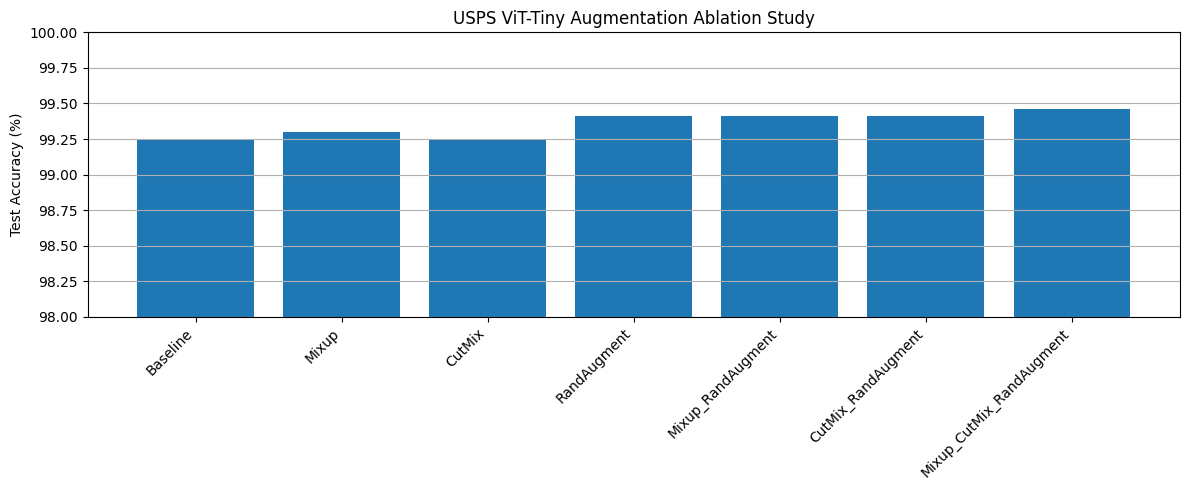

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))


plt.bar(
    results_df["Model"],
    results_df["Test Accuracy"]
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.ylabel(
    "Test Accuracy (%)"
)


plt.title(
    "USPS ViT-Tiny Augmentation Ablation Study"
)


plt.ylim(
    98,
    100
)


plt.grid(
    axis="y"
)


plt.tight_layout()


plt.show()

In [ ]:
results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Test Accuracy
6,Mixup_CutMix_RandAugment,99.46
3,RandAugment,99.41
4,Mixup_RandAugment,99.41
5,CutMix_RandAugment,99.41
1,Mixup,99.30
2,CutMix,99.25
0,Baseline,99.25


In [ ]:
baseline_acc = (
    results_df[
        results_df["Model"]=="Baseline"
    ]["Test Accuracy"]
    .values[0]
)


results_df["Improvement"] = (
    results_df["Test Accuracy"]
    -
    baseline_acc
)


results_df

,Model,Test Accuracy,Improvement
0,Baseline,99.25,0.00
1,Mixup,99.30,0.05
2,CutMix,99.25,0.00
3,RandAugment,99.41,0.16
4,Mixup_RandAugment,99.41,0.16
5,CutMix_RandAugment,99.41,0.16
6,Mixup_CutMix_RandAugment,99.46,0.21


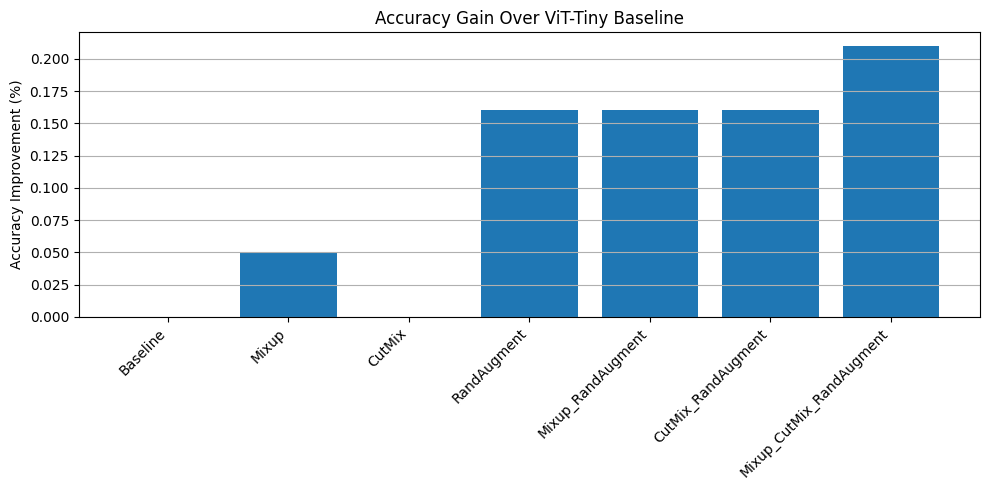

In [ ]:
plt.figure(figsize=(10,5))


plt.bar(
    results_df["Model"],
    results_df["Improvement"]
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.ylabel(
    "Accuracy Improvement (%)"
)


plt.title(
    "Accuracy Gain Over ViT-Tiny Baseline"
)


plt.grid(
    axis="y"
)


plt.tight_layout()


plt.savefig(
    "/content/drive/MyDrive/usps_vit_accuracy_improvement.png",
    dpi=300
)


plt.show()

In [ ]:
best_model_path = "/content/drive/MyDrive/usps_vit_tiny_mixup_cutmix_randaugment_best (1).pth"


best_model,_ = load_model(
    best_model_path
)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


y_true=[]
y_pred=[]


best_model.eval()


with torch.no_grad():

    for images,labels in test_loader:

        images=images.to(device)

        outputs=best_model(images)

        preds=torch.argmax(
            outputs,
            dim=1
        )


        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )


cm = confusion_matrix(
    y_true,
    y_pred
)

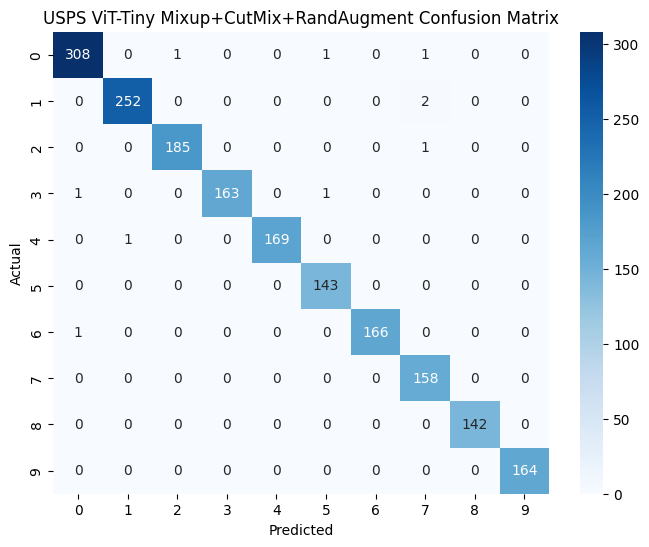

In [ ]:
plt.figure(figsize=(8,6))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.title(
    "USPS ViT-Tiny Mixup+CutMix+RandAugment Confusion Matrix"
)


plt.show()

In [ ]:
best_model,_ = load_model(best_model_path)

In [ ]:
y_true=[]
y_pred=[]


best_model.eval()


with torch.no_grad():

    for images,labels in test_loader:

        images = images.to(device)

        outputs = best_model(images)

        preds = torch.argmax(
            outputs,
            dim=1
        )


        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report


cm = confusion_matrix(
    y_true,
    y_pred
)


print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       311
           1       1.00      0.99      0.99       254
           2       0.99      0.99      0.99       186
           3       1.00      0.99      0.99       165
           4       1.00      0.99      1.00       170
           5       0.99      1.00      0.99       143
           6       1.00      0.99      1.00       167
           7       0.98      1.00      0.99       158
           8       1.00      1.00      1.00       142
           9       1.00      1.00      1.00       164

    accuracy                           0.99      1860
   macro avg       0.99      1.00      0.99      1860
weighted avg       0.99      0.99      0.99      1860



In [ ]:
import pandas as pd


report_dict = classification_report(

    y_true,

    y_pred,

    output_dict=True

)


report_df = pd.DataFrame(
    report_dict
).transpose()


report_df

,precision,recall,f1-score,support
0,0.993548,0.990354,0.991948,311.000000
1,0.996047,0.992126,0.994083,254.000000
2,0.994624,0.994624,0.994624,186.000000
3,1.000000,0.987879,0.993902,165.000000
4,1.000000,0.994118,0.997050,170.000000
5,0.986207,1.000000,0.993056,143.000000
6,1.000000,0.994012,0.996997,167.000000
7,0.975309,1.000000,0.987500,158.000000
8,1.000000,1.000000,1.000000,142.000000
9,1.000000,1.000000,1.000000,164.000000


In [ ]:
report_df.to_csv(
    "/content/drive/MyDrive/usps_best_model_classification_report.csv"
)

print("Saved")

Saved


In [ ]:
import numpy as np


y_true_np = np.array(y_true)

y_pred_np = np.array(y_pred)


wrong_indices = np.where(

    y_true_np != y_pred_np

)[0]


print(
    "Total wrong predictions:",
    len(wrong_indices)
)

Total wrong predictions: 10


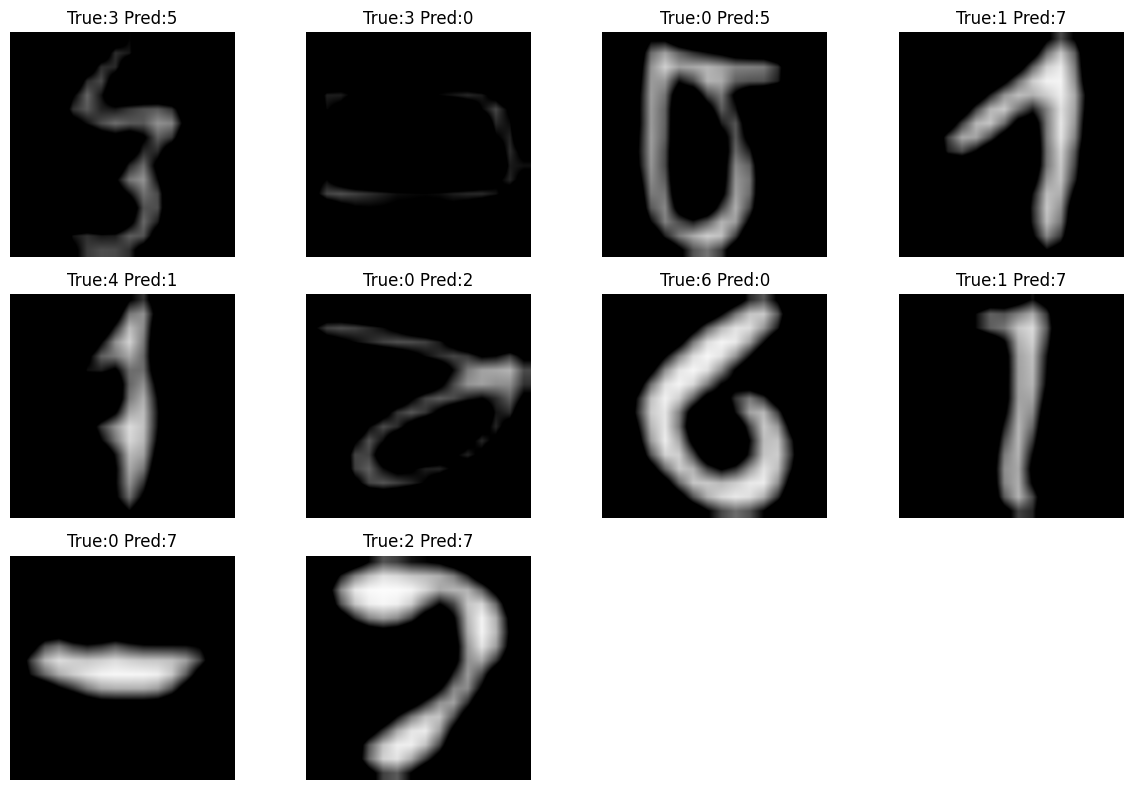

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,8))


for i,idx in enumerate(wrong_indices[:12]):


    image,label = test_dataset[idx]


    plt.subplot(3,4,i+1)


    img = image.permute(
        1,2,0
    ).cpu().numpy()


    img = (
        img * 0.5
    ) + 0.5


    plt.imshow(img)


    plt.title(
        f"True:{y_true[idx]} Pred:{y_pred[idx]}"
    )


    plt.axis("off")


plt.tight_layout()

plt.show()

In [ ]:
import numpy as np


cm_array = np.array(cm)


class_accuracy = (
    cm_array.diagonal()
    /
    cm_array.sum(axis=1)
) * 100


for i,acc in enumerate(class_accuracy):

    print(
        f"Digit {i}: {acc:.2f}%"
    )

Digit 0: 99.04%
Digit 1: 99.21%
Digit 2: 99.46%
Digit 3: 98.79%
Digit 4: 99.41%
Digit 5: 100.00%
Digit 6: 99.40%
Digit 7: 100.00%
Digit 8: 100.00%
Digit 9: 100.00%


In [ ]:
prediction_df = pd.DataFrame(

    {
        "True_Label": y_true,
        "Predicted_Label": y_pred
    }

)


prediction_df.to_csv(

    "/content/drive/MyDrive/usps_best_model_predictions.csv",

    index=False

)


print("Predictions saved")

Predictions saved


In [ ]:
results = [
    ["Baseline",99.25],
    ["Mixup",99.30],
    ["CutMix",99.25],
    ["RandAugment",99.41],
    ["Mixup + RandAugment",99.41],
    ["CutMix + RandAugment",99.41],
    ["Mixup + CutMix + RandAugment",99.46]
]

In [ ]:
import pandas as pd


results_df = pd.DataFrame(
    results,
    columns=[
        "Experiment",
        "Test Accuracy"
    ]
)


results_df

,Experiment,Test Accuracy
0,Baseline,99.25
1,Mixup,99.30
2,CutMix,99.25
3,RandAugment,99.41
4,Mixup + RandAugment,99.41
5,CutMix + RandAugment,99.41
6,Mixup + CutMix + RandAugment,99.46


In [ ]:
import pandas as pd


results_df = pd.DataFrame(
    results,
    columns=[
        "Experiment",
        "Test Accuracy"
    ]
)


results_df

,Experiment,Test Accuracy
0,Baseline,99.25
1,Mixup,99.30
2,CutMix,99.25
3,RandAugment,99.41
4,Mixup + RandAugment,99.41
5,CutMix + RandAugment,99.41
6,Mixup + CutMix + RandAugment,99.46


In [ ]:
baseline_acc = results_df.loc[
    results_df["Experiment"]=="Baseline",
    "Test Accuracy"
].values[0]


results_df["Improvement (%)"] = (
    results_df["Test Accuracy"]
    -
    baseline_acc
)


results_df

,Experiment,Test Accuracy,Improvement (%)
0,Baseline,99.25,0.00
1,Mixup,99.30,0.05
2,CutMix,99.25,0.00
3,RandAugment,99.41,0.16
4,Mixup + RandAugment,99.41,0.16
5,CutMix + RandAugment,99.41,0.16
6,Mixup + CutMix + RandAugment,99.46,0.21


In [ ]:
ranking_df = results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)


ranking_df.insert(
    0,
    "Rank",
    range(1,len(ranking_df)+1)
)


ranking_df

,Rank,Experiment,Test Accuracy,Improvement (%)
6,1,Mixup + CutMix + RandAugment,99.46,0.21
3,2,RandAugment,99.41,0.16
4,3,Mixup + RandAugment,99.41,0.16
5,4,CutMix + RandAugment,99.41,0.16
1,5,Mixup,99.30,0.05
2,6,CutMix,99.25,0.00
0,7,Baseline,99.25,0.00


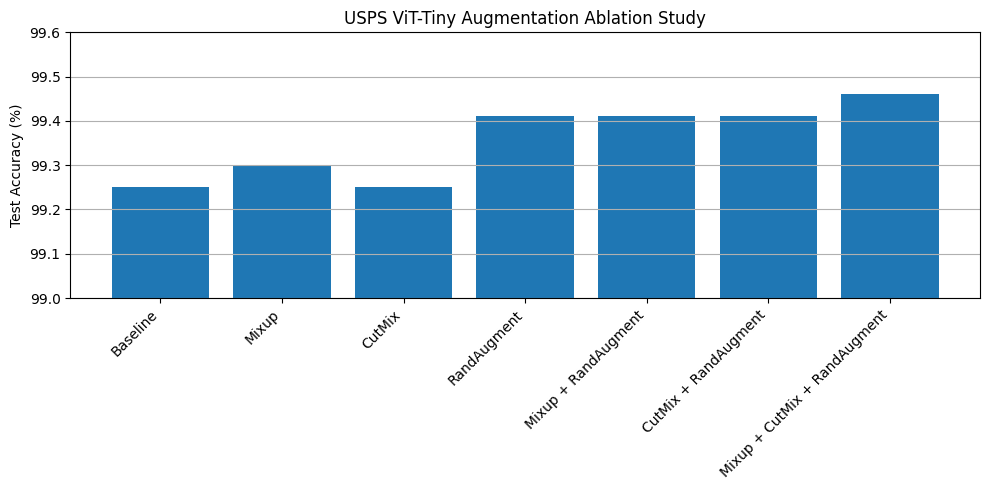

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))


plt.bar(
    results_df["Experiment"],
    results_df["Test Accuracy"]
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.ylabel(
    "Test Accuracy (%)"
)


plt.title(
    "USPS ViT-Tiny Augmentation Ablation Study"
)


# Zoom y-axis
plt.ylim(
    99.0,
    99.6
)


plt.grid(
    axis="y"
)


plt.tight_layout()


plt.savefig(
    "/content/drive/MyDrive/usps_accuracy_comparison_zoomed.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

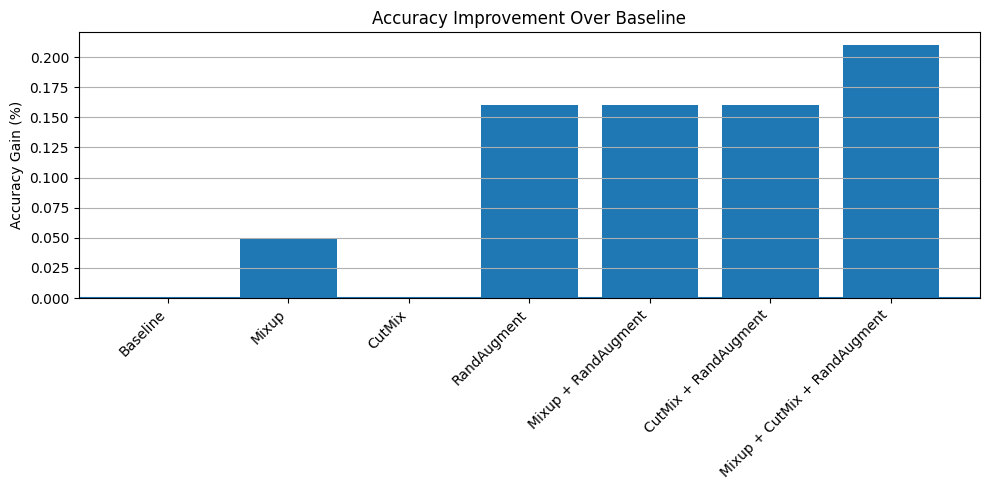

In [ ]:
plt.figure(figsize=(10,5))


plt.bar(
    results_df["Experiment"],
    results_df["Improvement (%)"]
)


plt.axhline(
    0
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.ylabel(
    "Accuracy Gain (%)"
)


plt.title(
    "Accuracy Improvement Over Baseline"
)


plt.grid(
    axis="y"
)


plt.tight_layout()


plt.savefig(
    "/content/drive/MyDrive/usps_baseline_improvement.png",
    dpi=300
)


plt.show()

In [ ]:
epochs = list(range(1,21))


train_loss = [
1.0389,
0.9845,
1.0000,
0.9696,
1.0180,
0.9586,
0.9658,
1.0097,
0.9621,
0.9634,
0.9535,
0.9780,
0.9457,
0.9685,
0.9452,
0.9610,
0.9485,
0.9075,
0.9365,
0.9519
]


val_loss = [
0.1764,
0.1680,
0.1779,
0.1747,
0.1720,
0.1679,
0.1689,
0.1660,
0.1483,
0.1741,
0.1527,
0.1595,
0.1543,
0.1482,
0.1453,
0.1476,
0.1471,
0.1427,
0.1441,
0.1438
]


val_accuracy = [
99.14,
99.25,
98.87,
98.92,
99.25,
99.03,
98.98,
99.25,
99.09,
99.03,
99.09,
99.14,
99.03,
99.25,
99.46,
99.46,
99.35,
99.35,
99.35,
99.35
]

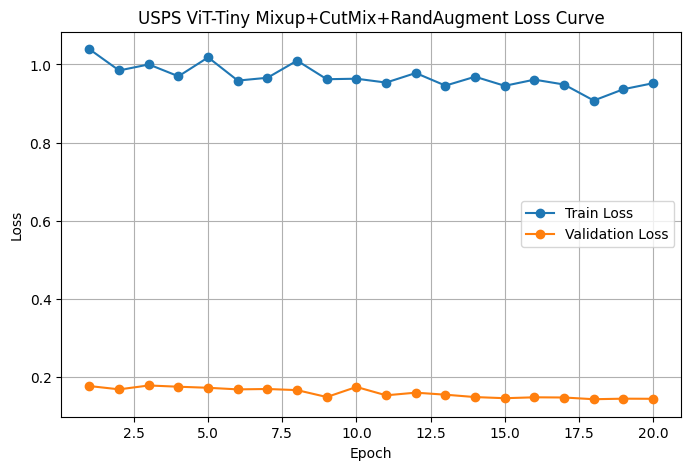

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


plt.plot(
    epochs,
    train_loss,
    marker="o",
    label="Train Loss"
)


plt.plot(
    epochs,
    val_loss,
    marker="o",
    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "USPS ViT-Tiny Mixup+CutMix+RandAugment Loss Curve"
)


plt.legend()


plt.grid()


plt.savefig(
    "/content/drive/MyDrive/usps_all_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

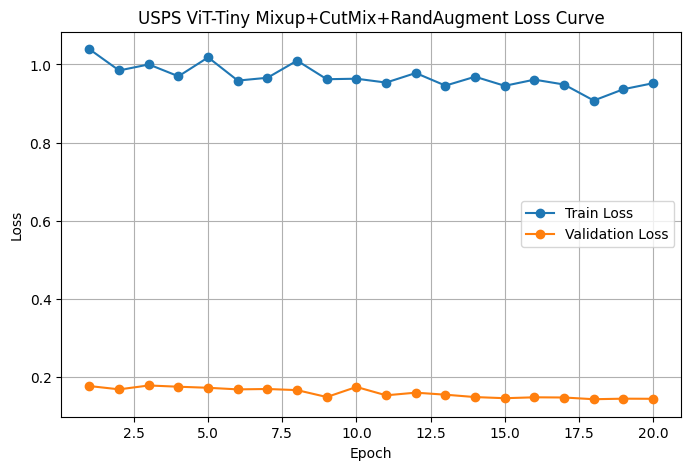

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


plt.plot(
    epochs,
    train_loss,
    marker="o",
    label="Train Loss"
)


plt.plot(
    epochs,
    val_loss,
    marker="o",
    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "USPS ViT-Tiny Mixup+CutMix+RandAugment Loss Curve"
)


plt.legend()


plt.grid()


plt.savefig(
    "/content/drive/MyDrive/usps_all_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# **RA**

In [ ]:
best_model_path = "/content/drive/MyDrive/usps_vit_tiny_mixup_cutmix_randaugment_best (1).pth"

In [ ]:
import torch
import timm


best_model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=10
)


state = torch.load(
    best_model_path,
    map_location=device
)


best_model.load_state_dict(
    state
)


best_model = best_model.to(device)

best_model.eval()


print("Best model loaded")

Best model loaded


In [ ]:
class GaussianNoiseDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        dataset,
        noise_factor=0.2
    ):

        self.dataset = dataset
        self.noise_factor = noise_factor


    def __len__(self):

        return len(self.dataset)


    def __getitem__(self,idx):

        image,label = self.dataset[idx]


        noise = torch.randn_like(image) * self.noise_factor


        noisy_image = image + noise


        noisy_image = torch.clamp(
            noisy_image,
            -1,
            1
        )


        return noisy_image,label

In [ ]:
noisy_dataset = GaussianNoiseDataset(
    test_dataset,
    noise_factor=0.2
)


noisy_loader = torch.utils.data.DataLoader(
    noisy_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
noisy_dataset = GaussianNoiseDataset(
    test_dataset,
    noise_factor=0.2
)


noisy_loader = torch.utils.data.DataLoader(
    noisy_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
def evaluate_accuracy(
    model,
    loader
):

    model.eval()

    correct=0
    total=0


    with torch.no_grad():

        for images,labels in loader:


            images=images.to(device)

            labels=labels.to(device)


            outputs=model(images)


            preds=torch.argmax(
                outputs,
                dim=1
            )


            correct += (
                preds==labels
            ).sum().item()


            total += labels.size(0)


    return 100*correct/total

In [ ]:
clean_acc = evaluate_accuracy(
    best_model,
    test_loader
)


noise_acc = evaluate_accuracy(
    best_model,
    noisy_loader
)


print(
    "Clean Accuracy:",
    clean_acc
)


print(
    "Gaussian Noise Accuracy:",
    noise_acc
)

Clean Accuracy: 99.46236559139786
Gaussian Noise Accuracy: 92.95698924731182


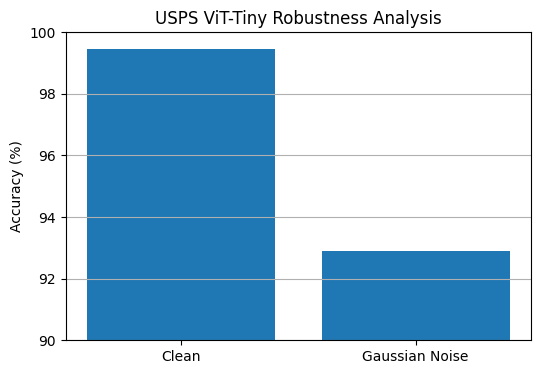

In [ ]:
import matplotlib.pyplot as plt


robustness_names=[
    "Clean",
    "Gaussian Noise"
]


robustness_values=[
    clean_acc,
    noise_acc
]


plt.figure(figsize=(6,4))


plt.bar(
    robustness_names,
    robustness_values
)


plt.ylabel(
    "Accuracy (%)"
)


plt.title(
    "USPS ViT-Tiny Robustness Analysis"
)


plt.ylim(
    90,
    100
)


plt.grid(
    axis="y"
)


plt.show()

In [ ]:
import torch
import timm


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


model_path = "/content/drive/MyDrive/usps_vit_tiny_mixup_cutmix_randaugment_best (1).pth"


robust_model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=10
)


state = torch.load(
    model_path,
    map_location=device
)


robust_model.load_state_dict(state)


robust_model = robust_model.to(device)

robust_model.eval()


print("Robustness model loaded")

Robustness model loaded


In [ ]:
class BrightnessDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        dataset,
        factor=1.5
    ):

        self.dataset=dataset
        self.factor=factor


    def __len__(self):

        return len(self.dataset)


    def __getitem__(self,index):

        image,label=self.dataset[index]


        image=image*self.factor


        image=torch.clamp(
            image,
            -1,
            1
        )


        return image,label

In [ ]:
brightness_dataset = BrightnessDataset(
    test_dataset,
    factor=1.5
)


brightness_loader=torch.utils.data.DataLoader(
    brightness_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
brightness_acc = evaluate_accuracy(
    robust_model,
    brightness_loader
)


print(
    "Brightness Accuracy:",
    brightness_acc
)

Brightness Accuracy: 84.89247311827957


In [ ]:
import torchvision.transforms.functional as TF


class BlurDataset(torch.utils.data.Dataset):

    def __init__(self,dataset):

        self.dataset=dataset


    def __len__(self):

        return len(self.dataset)


    def __getitem__(self,index):

        image,label=self.dataset[index]


        image=TF.gaussian_blur(
            image,
            kernel_size=5
        )


        return image,label

In [ ]:
blur_dataset = BlurDataset(
    test_dataset
)


blur_loader=torch.utils.data.DataLoader(
    blur_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
blur_acc=evaluate_accuracy(
    robust_model,
    blur_loader
)


print(
    "Blur Accuracy:",
    blur_acc
)

Blur Accuracy: 99.46236559139786


In [ ]:
class OcclusionDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        dataset,
        size=40
    ):

        self.dataset=dataset
        self.size=size


    def __len__(self):

        return len(self.dataset)


    def __getitem__(self,index):

        image,label=self.dataset[index]


        c,h,w=image.shape


        x=torch.randint(
            0,
            w-self.size,
            (1,)
        ).item()


        y=torch.randint(
            0,
            h-self.size,
            (1,)
        ).item()


        image[
            :,
            y:y+self.size,
            x:x+self.size
        ]=0


        return image,label

In [ ]:
occlusion_dataset = OcclusionDataset(
    test_dataset
)


occlusion_loader=torch.utils.data.DataLoader(
    occlusion_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
occlusion_acc=evaluate_accuracy(
    robust_model,
    occlusion_loader
)


print(
    "Occlusion Accuracy:",
    occlusion_acc
)

Occlusion Accuracy: 99.3010752688172


In [ ]:
import pandas as pd


robustness_results = pd.DataFrame({

    "Condition":[
        "Clean",
        "Gaussian Noise",
        "Brightness",
        "Blur",
        "Occlusion"
    ],

    "Accuracy":[
        99.46,
        92.96,
        84.89,
        99.46,
        99.30
    ]

})


robustness_results

,Condition,Accuracy
0,Clean,99.46
1,Gaussian Noise,92.96
2,Brightness,84.89
3,Blur,99.46
4,Occlusion,99.30


# **AV**

In [ ]:
import gc
import torch

try:
    del best_model
except:
    pass

gc.collect()
torch.cuda.empty_cache()

print("Cleaned")

Cleaned


In [ ]:
import timm
import torch


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


best_model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=10
)


checkpoint = torch.load(
    "/content/drive/MyDrive/usps_vit_tiny_mixup_cutmix_randaugment_best (1).pth",
    map_location=device
)


best_model.load_state_dict(checkpoint)


best_model = best_model.to(device)

best_model.eval()


print("Model loaded")

Model loaded


In [ ]:
image,label = test_dataset[0]


img = image.unsqueeze(0).to(device)


with torch.no_grad():

    output = best_model(img)


print(output.shape)

pred = torch.argmax(output,dim=1)


print(
    "Prediction:",
    pred.item()
)

print(
    "True:",
    label
)

torch.Size([1, 10])
Prediction: 0
True: 0


In [ ]:
attention_maps = []


def get_attention_from_block(block, x):


    B,N,C = x.shape


    qkv = block.attn.qkv(x)


    qkv = qkv.reshape(
        B,
        N,
        3,
        block.attn.num_heads,
        C // block.attn.num_heads
    )


    qkv = qkv.permute(
        2,
        0,
        3,
        1,
        4
    )


    q = qkv[0]
    k = qkv[1]


    attn = (
        q @ k.transpose(-2,-1)
    )


    attn = attn * block.attn.scale


    attn = torch.softmax(
        attn,
        dim=-1
    )


    return attn

In [ ]:
with torch.no_grad():

    x = best_model.patch_embed(img)


    cls_token = best_model.cls_token.expand(
        x.shape[0],
        -1,
        -1
    )


    x = torch.cat(
        (cls_token,x),
        dim=1
    )


    x = x + best_model.pos_embed


    x = best_model.pos_drop(x)



    for i,block in enumerate(best_model.blocks):

        if i == len(best_model.blocks)-1:

            attn = get_attention_from_block(
                block,
                x
            )


        x = block(x)

In [ ]:
print(attn.shape)

torch.Size([1, 3, 197, 197])


In [ ]:
cls_attn = attn[0,:,0,1:]


cls_attn = cls_attn.mean(
    dim=0
)


attention_map = cls_attn.reshape(
    14,
    14
)


attention_map = attention_map.cpu().numpy()

In [ ]:
attention_map = (
    attention_map - attention_map.min()
) / (
    attention_map.max()-attention_map.min()
)

In [ ]:
import cv2


attention_map = cv2.resize(
    attention_map,
    (224,224)
)

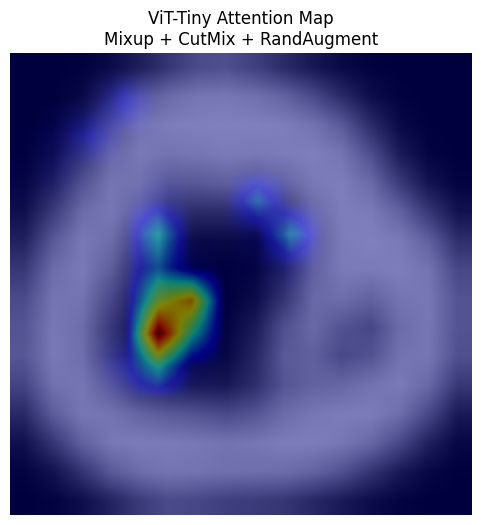

In [ ]:
import matplotlib.pyplot as plt


original = image.permute(
    1,2,0
).cpu()


plt.figure(figsize=(6,6))


plt.imshow(
    original[:,:,0],
    cmap="gray"
)


plt.imshow(
    attention_map,
    cmap="jet",
    alpha=0.5
)


plt.title(
    "ViT-Tiny Attention Map\nMixup + CutMix + RandAugment"
)


plt.axis("off")


plt.show()

In [ ]:
import gc

try:
    del best_model

except:
    pass


gc.collect()

torch.cuda.empty_cache()

In [ ]:
attention_model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=10
)


state=torch.load(
    model_path,
    map_location=device
)


attention_model.load_state_dict(
    state
)


attention_model=attention_model.to(device)

attention_model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [ ]:
def get_attention(model,image):


    img=image.unsqueeze(0).to(device)


    with torch.no_grad():

        x=model.patch_embed(img)


        cls=model.cls_token.expand(
            x.shape[0],
            -1,
            -1
        )


        x=torch.cat(
            [cls,x],
            dim=1
        )


        x=x+model.pos_embed


        x=model.pos_drop(x)


        for i,block in enumerate(model.blocks):


            if i==11:

                B,N,C=x.shape


                qkv=block.attn.qkv(x)


                qkv=qkv.reshape(
                    B,
                    N,
                    3,
                    block.attn.num_heads,
                    C//block.attn.num_heads
                )


                qkv=qkv.permute(
                    2,0,3,1,4
                )


                q=qkv[0]

                k=qkv[1]


                attn=(q @ k.transpose(-2,-1))


                attn=attn*block.attn.scale


                attn=torch.softmax(
                    attn,
                    dim=-1
                )

            x=block(x)


    return attn.cpu()

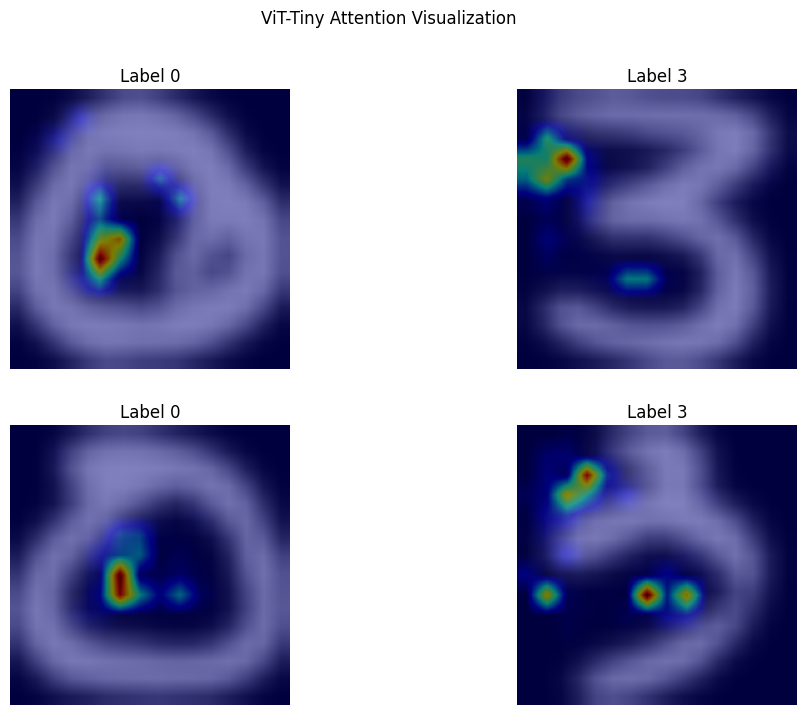

In [ ]:
import matplotlib.pyplot as plt
import cv2


samples=[0,10,50,100]


plt.figure(figsize=(12,8))


for i,index in enumerate(samples):


    image,label=test_dataset[index]


    attn=get_attention(
        attention_model,
        image
    )


    cls_attn=attn[0,:,0,1:]


    cls_attn=cls_attn.mean(
        dim=0
    )


    heatmap=cls_attn.reshape(
        14,
        14
    )


    heatmap=heatmap.numpy()


    heatmap=cv2.resize(
        heatmap,
        (224,224)
    )


    heatmap=(
        heatmap-heatmap.min()
    )/(
        heatmap.max()-heatmap.min()
    )


    img=image.permute(
        1,2,0
    )


    plt.subplot(
        2,
        2,
        i+1
    )


    plt.imshow(
        img[:,:,0],
        cmap="gray"
    )


    plt.imshow(
        heatmap,
        cmap="jet",
        alpha=0.5
    )


    plt.title(
        f"Label {label}"
    )


    plt.axis("off")


plt.suptitle(
    "ViT-Tiny Attention Visualization"
)


plt.show()

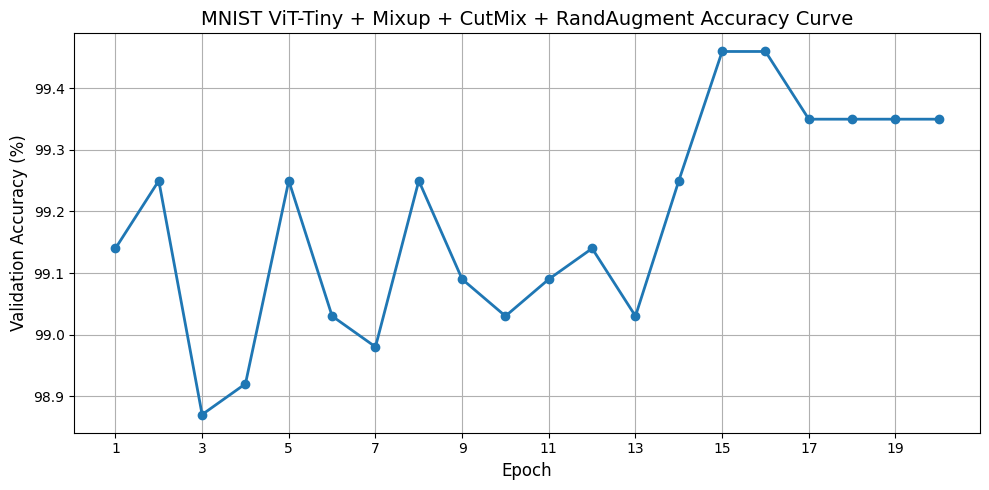

In [ ]:
# ================================
# MNIST ViT-Tiny + Mixup + CutMix + RandAugment
# Accuracy Curve Plot
# ================================

import matplotlib.pyplot as plt
import pandas as pd


# Validation accuracy values from training logs
epochs = list(range(1, 21))

val_accuracy = [
    99.14,
    99.25,
    98.87,
    98.92,
    99.25,
    99.03,
    98.98,
    99.25,
    99.09,
    99.03,
    99.09,
    99.14,
    99.03,
    99.25,
    99.46,
    99.46,
    99.35,
    99.35,
    99.35,
    99.35
]


# Create dataframe
results_df = pd.DataFrame({
    "Epoch": epochs,
    "Validation Accuracy (%)": val_accuracy
})


# ================================
# Plot Accuracy Curve
# ================================

plt.figure(figsize=(10,5))


plt.plot(
    results_df["Epoch"],
    results_df["Validation Accuracy (%)"],
    marker="o",
    linewidth=2
)


plt.xlabel(
    "Epoch",
    fontsize=12
)

plt.ylabel(
    "Validation Accuracy (%)",
    fontsize=12
)


plt.title(
    "MNIST ViT-Tiny + Mixup + CutMix + RandAugment Accuracy Curve",
    fontsize=14
)


plt.grid(True)


plt.xticks(
    range(1,21,2)
)


plt.tight_layout()


# Save figure
plt.savefig(
    "mnist_vit_tiny_mixup_cutmix_randaugment_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
model = timm.create_model(
    "vit_small_patch16_224",
    pretrained=True,
    num_classes=100
)

print(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total:", total_params)
print("Trainable:", trainable_params)

Total: 21704164
Trainable: 21704164


In [ ]:
model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=True,
    num_classes=10
)

print(model)

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total:", total_params)
print("Trainable:", trainable_params)

Total: 5526346
Trainable: 5526346


In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1,21))

# USPS
usps_acc = [
    99.14,
    99.25,
    98.87,
    98.92,
    99.25,
    99.03,
    98.98,
    99.25,
    99.09,
    99.03,
    99.09,
    99.14,
    99.03,
    99.25,
    99.46,
    99.46,
    99.35,
    99.35,
    99.35,
    99.35
]

# MNIST
mnist_acc = [
    99.71,
    99.71,
    99.68,
    99.68,
    99.64,
    99.71,
    99.73,
    99.59,
    99.69,
    99.63,
    99.69,
    99.59,
    99.58,
    99.59,
    99.57,
    99.60,
    99.54,
    99.61,
    99.61,
    99.63
]

# CIFAR100
cifar_acc = [
    70.70,
    76.98,
    79.24,
    80.60,
    82.20,
    82.59,
    83.95,
    84.18,
    84.64,
    84.89,
    85.59,
    86.14,
    86.39,
    86.40,
    86.79,
    87.05,
    87.24,
    87.35,
    87.36,
    87.41
]

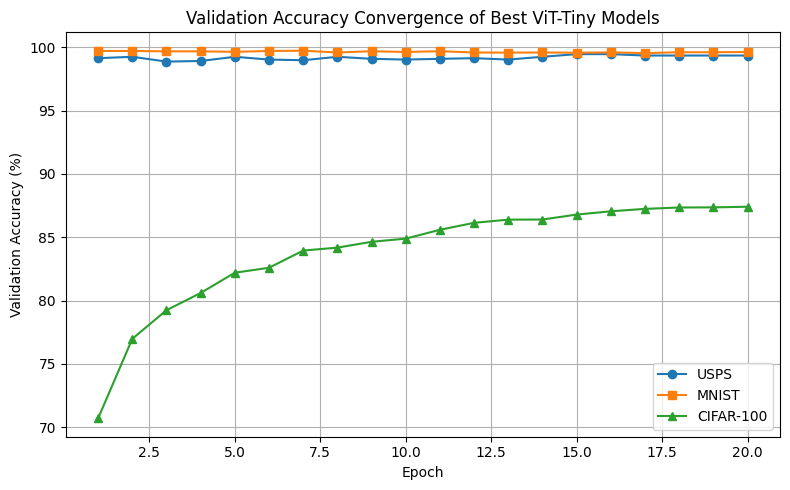

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    usps_acc,
    marker='o',
    label='USPS'
)

plt.plot(
    epochs,
    mnist_acc,
    marker='s',
    label='MNIST'
)

plt.plot(
    epochs,
    cifar_acc,
    marker='^',
    label='CIFAR-100'
)

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy (%)")

plt.title(
    "Validation Accuracy Convergence of Best ViT-Tiny Models"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "combined_accuracy_curves.png",
    dpi=300
)

plt.show()

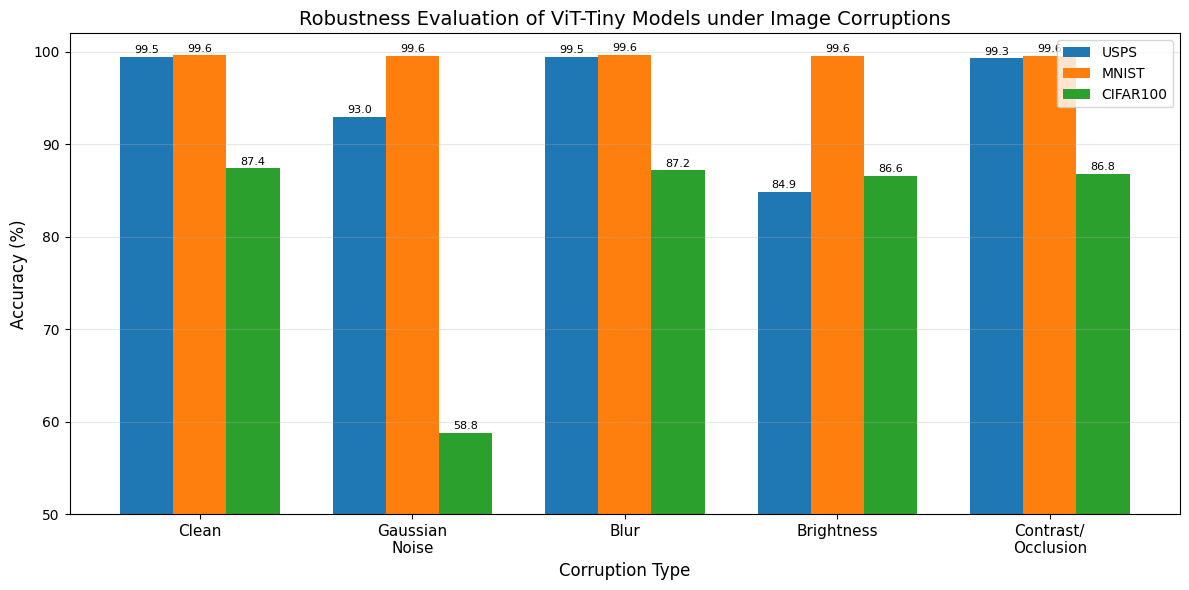

In [ ]:
# ==========================================
# Robustness Analysis Plot
# USPS + MNIST + CIFAR100
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# Conditions
conditions = [
    "Clean",
    "Gaussian\nNoise",
    "Blur",
    "Brightness",
    "Contrast/\nOcclusion"
]

# Accuracy values
mnist = [99.61, 99.58, 99.64, 99.56, 99.58]

# USPS has Occlusion instead of Contrast
usps = [99.46, 92.96, 99.46, 84.89, 99.30]

cifar100 = [87.41, 58.80, 87.20, 86.59, 86.83]

# X locations
x = np.arange(len(conditions))
width = 0.25

# Figure
plt.figure(figsize=(12,6))

# Bars
plt.bar(x-width, usps, width, label='USPS')
plt.bar(x, mnist, width, label='MNIST')
plt.bar(x+width, cifar100, width, label='CIFAR100')

# Labels
plt.xticks(x, conditions, fontsize=11)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Corruption Type', fontsize=12)

plt.title(
    'Robustness Evaluation of ViT-Tiny Models under Image Corruptions',
    fontsize=14
)

plt.ylim(50, 102)

# Add values on bars
for i,v in enumerate(usps):
    plt.text(i-width, v+0.4, f'{v:.1f}',
             ha='center', fontsize=8)

for i,v in enumerate(mnist):
    plt.text(i, v+0.4, f'{v:.1f}',
             ha='center', fontsize=8)

for i,v in enumerate(cifar100):
    plt.text(i+width, v+0.4, f'{v:.1f}',
             ha='center', fontsize=8)

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

# save for paper
plt.savefig(
    'robustness_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

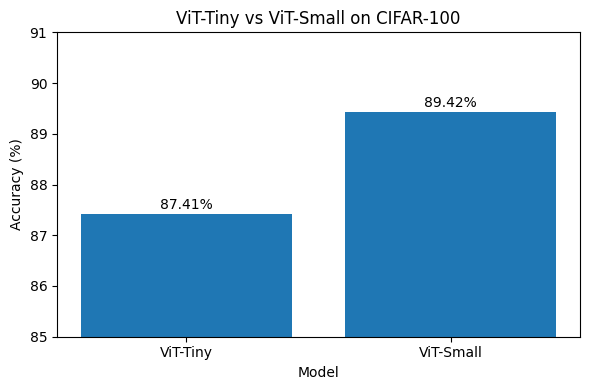

In [ ]:
import matplotlib.pyplot as plt

models = ['ViT-Tiny', 'ViT-Small']
accuracy = [87.41, 89.42]

plt.figure(figsize=(6,4))
bars = plt.bar(models, accuracy)

plt.ylabel('Accuracy (%)')
plt.xlabel('Model')
plt.title('ViT-Tiny vs ViT-Small on CIFAR-100')

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.1,
        f'{bar.get_height():.2f}%',
        ha='center'
    )

plt.ylim(85,91)
plt.tight_layout()

plt.savefig('vit_scaling.png', dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Augmentation methods
methods = [
    'Base',
    'Mixup',
    'CutMix',
    'RandAug',
    'M+C',
    'M+R',
    'C+R',
    'All'
]

# USPS
usps = [
    99.25,
    99.30,
    99.25,
    99.41,
    np.nan,      # not performed
    99.41,
    99.41,
    99.46
]

# MNIST
mnist = [
    99.66,
    99.67,
    99.68,
    99.62,
    99.65,
    99.73,
    99.64,
    99.69
]

# CIFAR100
cifar = [
    86.96,
    86.02,
    86.91,
    86.78,
    87.00,
    86.20,
    87.41,
    87.16
]

x = np.arange(len(methods))
width = 0.25

plt.figure(figsize=(14,6))

plt.bar(x-width, usps, width, label='USPS')
plt.bar(x, mnist, width, label='MNIST')
plt.bar(x+width, cifar, width, label='CIFAR-100')

plt.xticks(x, methods, rotation=30)
plt.ylabel('Accuracy (%)')
plt.xlabel('Augmentation Strategy')
plt.title('Performance of Augmentation Strategies Across Datasets')
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    'augmentation_ablation_all.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

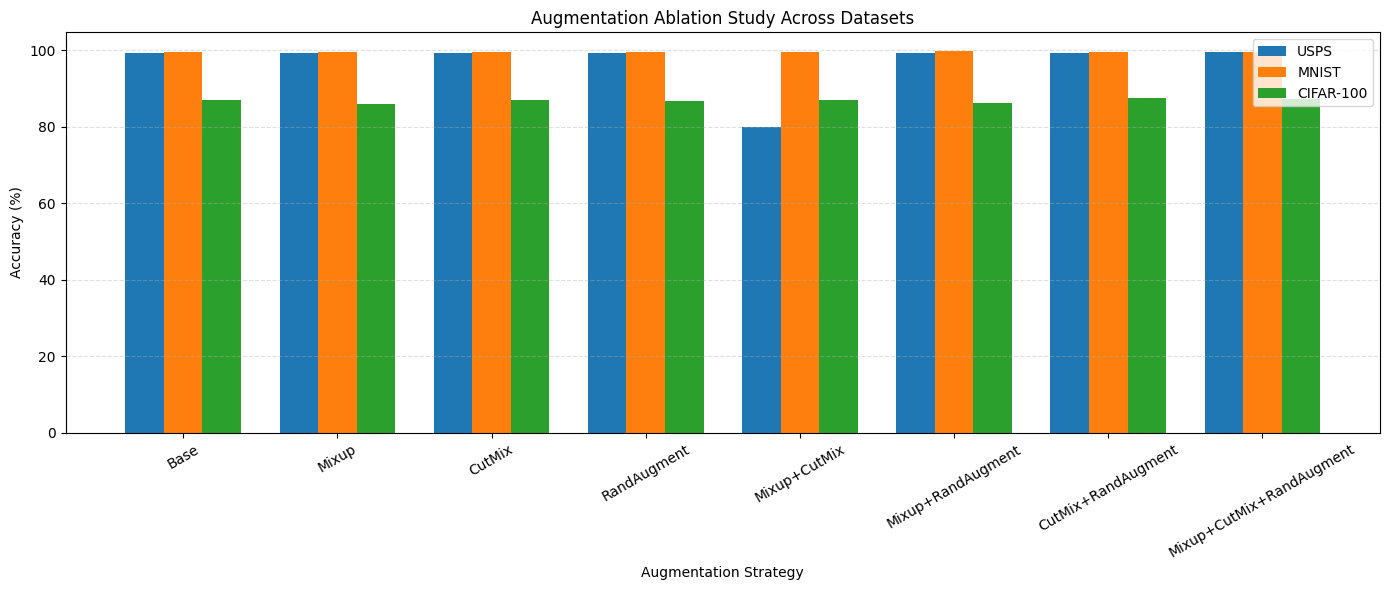

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

methods = [
    'Base',
    'Mixup',
    'CutMix',
    'RandAugment',
    'Mixup+CutMix',
    'Mixup+RandAugment',
    'CutMix+RandAugment',
    'Mixup+CutMix+RandAugment'
]

# USPS
usps = [
    99.25,
    99.30,
    99.25,
    99.41,
    80.05,     # Mixup+CutMix
    99.41,
    99.41,
    99.46
]

# MNIST
mnist = [
    99.66,
    99.67,
    99.68,
    99.62,
    99.65,
    99.73,
    99.64,
    99.69
]

# CIFAR100
cifar = [
    86.96,
    86.02,
    86.91,
    86.78,
    87.07,
    86.20,
    87.41,
    87.16
]

x = np.arange(len(methods))
width = 0.25

plt.figure(figsize=(14,6))

plt.bar(x-width, usps, width, label='USPS')
plt.bar(x, mnist, width, label='MNIST')
plt.bar(x+width, cifar, width, label='CIFAR-100')

plt.xticks(x, methods, rotation=30)
plt.ylabel('Accuracy (%)')
plt.xlabel('Augmentation Strategy')
plt.title('Augmentation Ablation Study Across Datasets')
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    "augmentation_ablation_all.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()